<a href="https://colab.research.google.com/github/springboardmentor1210a/Supportlytics/blob/JagannathReddy%2FSupportlytics/Infosys_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Saving customer_support_tickets.csv to customer_support_tickets (9).csv


/tmp/ipykernel_16918/2193378838.py:27: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['First Response Hours'] = (df['First Response Time'] - pd.to_datetime(df['Date of Purchase'])).dt.total_seconds() / 3600
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


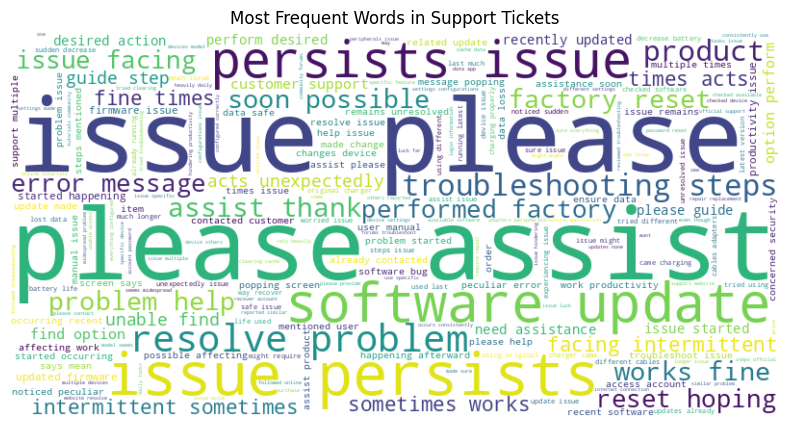

Average First Response Time (Hours): 21232.943359882007
Average Resolution Time (Hours): -0.05770434573251475

Ticket Type Distribution:
Ticket Type
Refund request          20.687212
Technical issue         20.628173
Cancellation request    20.014169
Product inquiry         19.376550
Billing inquiry         19.293895
Name: proportion, dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from wordcloud import WordCloud
import nltk
nltk.download('punkt')
nltk.download('stopwords')

# Load data
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("customer_support_tickets.csv")

# Data Cleaning
# Handle missing values
df.fillna({'Resolution': 'Unresolved', 'Customer Satisfaction Rating': 0}, inplace=True)

# Convert dates to datetime
df['First Response Time'] = pd.to_datetime(df['First Response Time'], format='%d-%m-%Y %H:%M')
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'], format='%d-%m-%Y %H:%M')

# Calculate response times in hours
df['First Response Hours'] = (df['First Response Time'] - pd.to_datetime(df['Date of Purchase'])).dt.total_seconds() / 3600
df['Resolution Hours'] = (df['Time to Resolution'] - df['First Response Time']).dt.total_seconds() / 3600

import nltk
nltk.download('punkt_tab') # Download the punkt_tab data package

# Text Analysis for Common Issues
stop_words = set(stopwords.words('english'))
ticket_text = " ".join(df['Ticket Description'].dropna().astype(str))
words = word_tokenize(ticket_text.lower())
filtered_words = [word for word in words if word.isalpha() and word not in stop_words]
common_words = FreqDist(filtered_words).most_common(20)

# Generate Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(filtered_words))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Support Tickets")
plt.show()

# Summary Statistics
print("Average First Response Time (Hours):", df['First Response Hours'].mean())
print("Average Resolution Time (Hours):", df['Resolution Hours'].mean())
print("\nTicket Type Distribution:")
print(df['Ticket Type'].value_counts(normalize=True) * 100)

# Export Cleaned Data for Tableau
df.to_csv('cleaned_support_tickets.csv', index=False)
files.download('cleaned_support_tickets.csv')

# **Missing values and Datatypes**

In [ ]:
# Import libraries
import pandas as pd
from google.colab import files

# Upload CSV file
uploaded = files.upload()

# Get the uploaded file name
file_name = list(uploaded.keys())[0]

# Read the CSV file
df = pd.read_csv(file_name)

# Dataset Information

print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print("\n" + "="*60)
print("COLUMN NAMES")
print("="*60)
print(df.columns.tolist())

# Data Types

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes)

# Missing Values

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

# Missing Value Percentage

print("\n" + "="*60)
print("MISSING VALUE PERCENTAGE")
print("="*60)

missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent.round(2))
# Summary Table

summary = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Missing Percentage (%)": ((df.isnull().sum() / len(df)) * 100).round(2).values
})

print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(summary)

# Optional: Save the summary as CSV
summary.to_csv("Data_Summary_Report.csv", index=False)

print("\nData Summary Report saved successfully!")

Saving customer_support_tickets.csv to customer_support_tickets (6).csv
DATASET SHAPE
(8469, 17)

COLUMN NAMES
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']

DATA TYPES
Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution                       object
Ticket Priority                  object
Ticket Channel                  

# **Ticket Type Distribution**

Ticket Type Distribution
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


/tmp/ipykernel_16918/4229386725.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Ticket Type', palette='Set2')


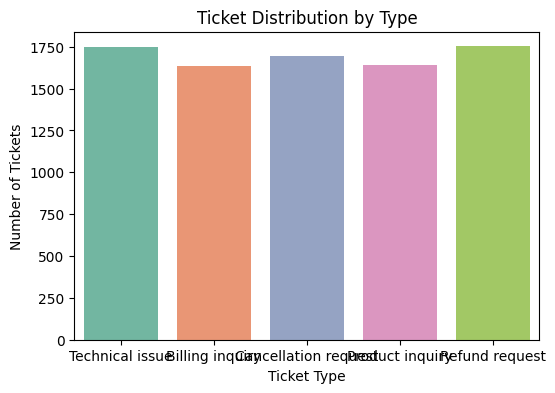

Ticket Priority Distribution
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


/tmp/ipykernel_16918/4229386725.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Ticket Priority',


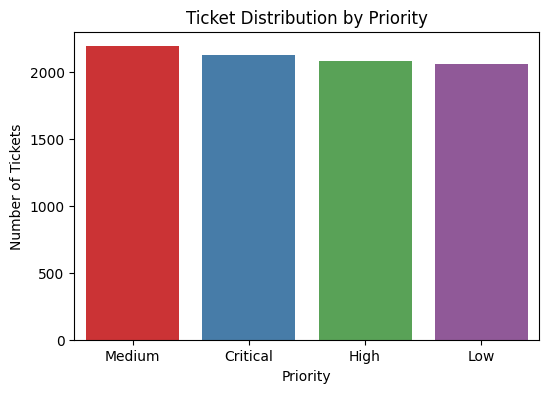

Ticket Category Distribution
Ticket Subject
Refund request           576
Software bug             574
Product compatibility    567
Delivery problem         561
Hardware issue           547
Battery life             542
Network problem          539
Installation support     530
Product setup            529
Payment issue            526
Name: count, dtype: int64


/tmp/ipykernel_16918/4229386725.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,


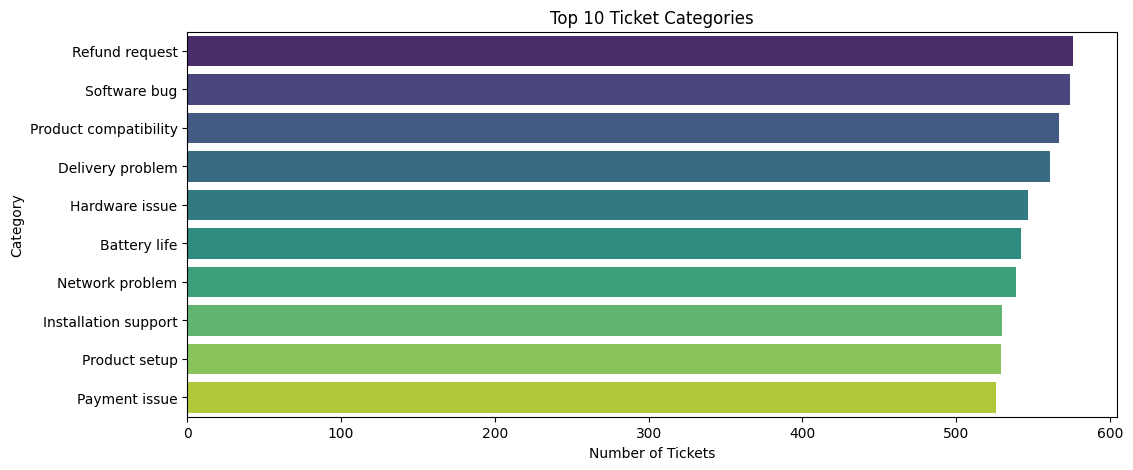

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ticket Type Distribution
print("="*50)
print("Ticket Type Distribution")
print("="*50)

type_distribution = df['Ticket Type'].value_counts()

print(type_distribution)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Ticket Type', palette='Set2')
plt.title("Ticket Distribution by Type")
plt.xlabel("Ticket Type")
plt.ylabel("Number of Tickets")
plt.show()

# Ticket Priority Distribution
print("="*50)
print("Ticket Priority Distribution")
print("="*50)

priority_distribution = df['Ticket Priority'].value_counts()

print(priority_distribution)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Ticket Priority',
              order=df['Ticket Priority'].value_counts().index,
              palette='Set1')

plt.title("Ticket Distribution by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.show()

# Ticket Category Distribution
print("="*50)
print("Ticket Category Distribution")
print("="*50)

category_distribution = df['Ticket Subject'].value_counts()

print(category_distribution.head(10))

plt.figure(figsize=(12,5))
sns.countplot(data=df,
              y='Ticket Subject',
              order=df['Ticket Subject'].value_counts().head(10).index,
              palette='viridis')

plt.title("Top 10 Ticket Categories")
plt.xlabel("Number of Tickets")
plt.ylabel("Category")
plt.show()

# Creating new **features**

In [ ]:
import pandas as pd
from google.colab import files

# Upload the dataset
uploaded = files.upload()

# Read the uploaded CSV file
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Convert date columns to datetime
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'], format='%d-%m-%Y')
df['First Response Time'] = pd.to_datetime(df['First Response Time'], format='%d-%m-%Y %H:%M')
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'], format='%d-%m-%Y %H:%M')

# Create Resolution_Duration (in hours)
df['Resolution_Duration'] = (
    df['Time to Resolution'] - df['Date of Purchase']
).dt.total_seconds() / 3600

# Create Priority_Score
priority_score = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Critical': 4
}

df['Priority_Score'] = df['Ticket Priority'].map(priority_score)

# Display the new columns
print("New Features Created Successfully!\n")

print(df[['Ticket Priority',
          'Priority_Score',
          'Resolution_Duration']].head())

# Display dataset information
print("\nDataset Shape:", df.shape)
print("\nColumns after Feature Engineering:")
print(df.columns)

Saving customer_support_tickets.csv to customer_support_tickets (8).csv
New Features Created Successfully!

  Ticket Priority  Priority_Score  Resolution_Duration
0        Critical               4                  NaN
1        Critical               4                  NaN
2             Low               1         25266.083333
3             Low               1         22321.950000
4             Low               1         29131.883333

Dataset Shape: (8469, 19)

Columns after Feature Engineering:
Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating', 'Resolution_Duration',
       'Priority_Score'],
      dtype='object')
